# 01 — Exploratory Data Analysis
Used Car Price Prediction and Analysis System — HOCO492 Mini Project

This notebook explores the raw CarDekho used-car dataset (`data/raw/used_cars.csv`) before any modelling. All numbers and plots below are generated directly from the dataset at run time.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_raw_data
from src.preprocessing import clean_raw_data
from src.feature_engineering import engineer_features
from src.config import FIGURES_DIR

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Dataset Shape

In [2]:
df_raw = load_raw_data()
print(f'Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}')

Rows: 8128, Columns: 13


## 2. First Five Rows

In [3]:
df_raw.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


## 3. Last Five Rows

In [4]:
df_raw.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)",5.0
8125,Maruti Swift Dzire ZDi,2009,382000,120000,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0
8127,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


## 4. Data Types

In [5]:
df_raw.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage           object
engine            object
max_power         object
torque            object
seats            float64
dtype: object

## 5. Statistical Summary

In [6]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
name,8128,2058,Maruti Swift Dzire VDI,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,8128.0,NaN,NaN,NaN,2013.804011,4.044249,1983.0,2011.0,2015.0,2017.0,2020.0
selling_price,8128.0,NaN,NaN,NaN,638271.807702,806253.403508,29999.0,254999.0,450000.0,675000.0,10000000.0
km_driven,8128.0,NaN,NaN,NaN,69819.510827,56550.554958,1.0,35000.0,60000.0,98000.0,2360457.0
fuel,8128,4,Diesel,4402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seller_type,8128,3,Individual,6766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transmission,8128,2,Manual,7078,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,8128,5,First Owner,5289,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,7907,393,18.9 kmpl,225,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,7907,121,1248 CC,1017,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Missing Value Analysis

In [7]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct}).sort_values('missing_count', ascending=False)

,missing_count,missing_pct
torque,222,2.73
seats,221,2.72
engine,221,2.72
mileage,221,2.72
max_power,215,2.65
fuel,0,0.00
km_driven,0,0.00
selling_price,0,0.00
year,0,0.00
name,0,0.00


## 7. Duplicate Analysis

In [8]:
n_dupes = df_raw.duplicated().sum()
print(f'Exact duplicate rows: {n_dupes} ({n_dupes/len(df_raw)*100:.1f}% of raw data)')

Exact duplicate rows: 1202 (14.8% of raw data)


## Cleaning + Feature Engineering (for the remaining analysis)
Using the same `clean_raw_data` / `engineer_features` functions as the production training pipeline (`src/train.py`), so this EDA reflects the data the models are actually trained on.

In [9]:
df = engineer_features(clean_raw_data(df_raw))
print(f'Rows after cleaning: {df.shape[0]} (dropped {df_raw.shape[0]-df.shape[0]})')
df[['car_age','brand']].head()

Rows after cleaning: 6924 (dropped 1204)


,car_age,brand
0,10,Maruti
1,10,Skoda
2,18,Honda
3,14,Hyundai
4,17,Maruti


## 8. Target Distribution (`selling_price`)

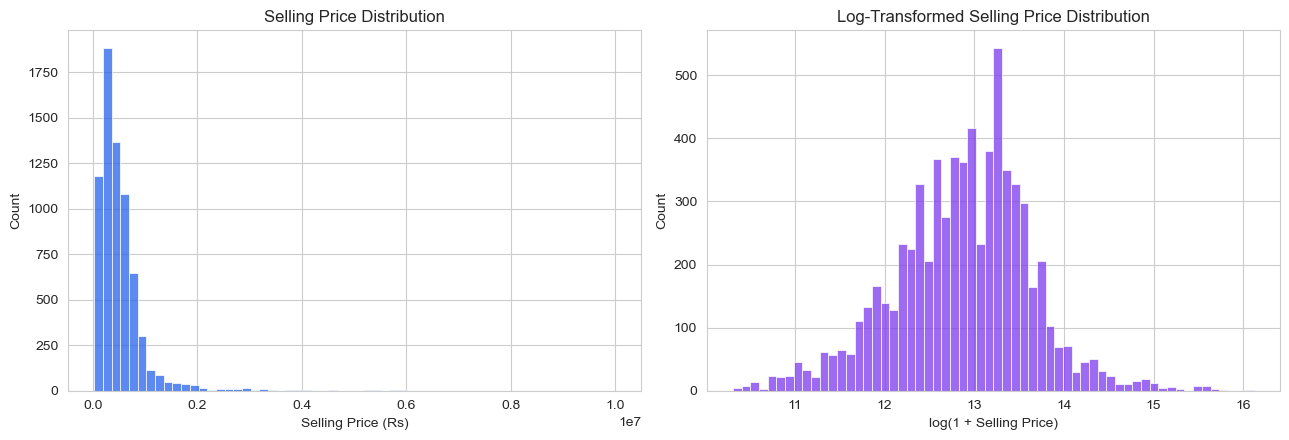

Selling price is strongly right-skewed (long tail of expensive cars); a log transform makes it closer to symmetric — useful context for why tree-based models, which do not assume a linear/normal relationship, tend to perform well here.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df['selling_price'], bins=60, ax=axes[0], color='#2563eb')
axes[0].set_title('Selling Price Distribution')
axes[0].set_xlabel('Selling Price (Rs)'); axes[0].set_ylabel('Count')
sns.histplot(np.log1p(df['selling_price']), bins=60, ax=axes[1], color='#7c3aed')
axes[1].set_title('Log-Transformed Selling Price Distribution')
axes[1].set_xlabel('log(1 + Selling Price)'); axes[1].set_ylabel('Count')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'target_distribution.png', dpi=150)
plt.show()
print('Selling price is strongly right-skewed (long tail of expensive cars); a log transform makes it closer to symmetric — useful context for why tree-based models, which do not assume a linear/normal relationship, tend to perform well here.')

## 9. Numerical Feature Distributions

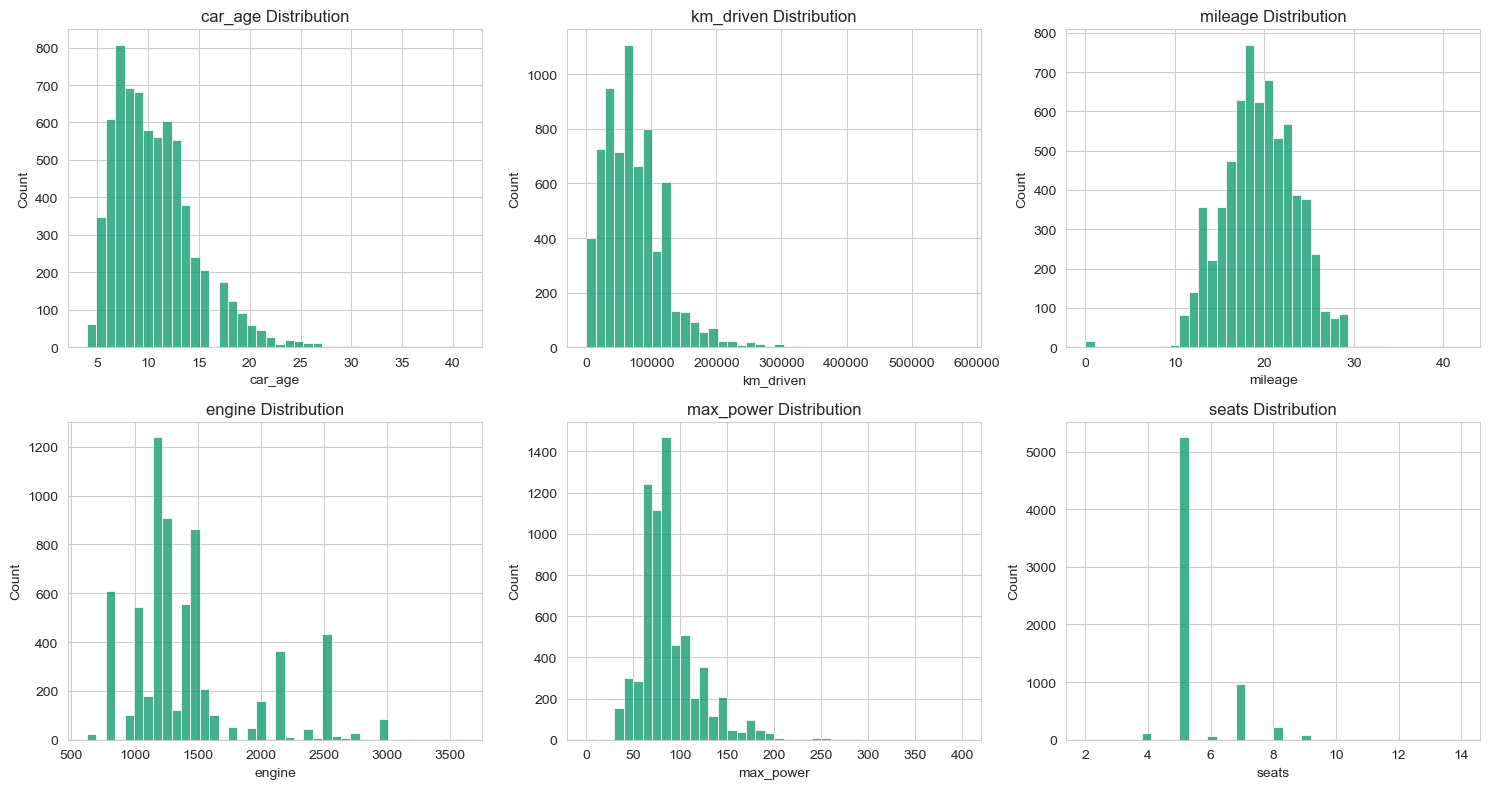

In [11]:
num_cols = ['car_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color='#059669')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'numerical_distributions.png', dpi=150)
plt.show()

## 10. Categorical Feature Distributions

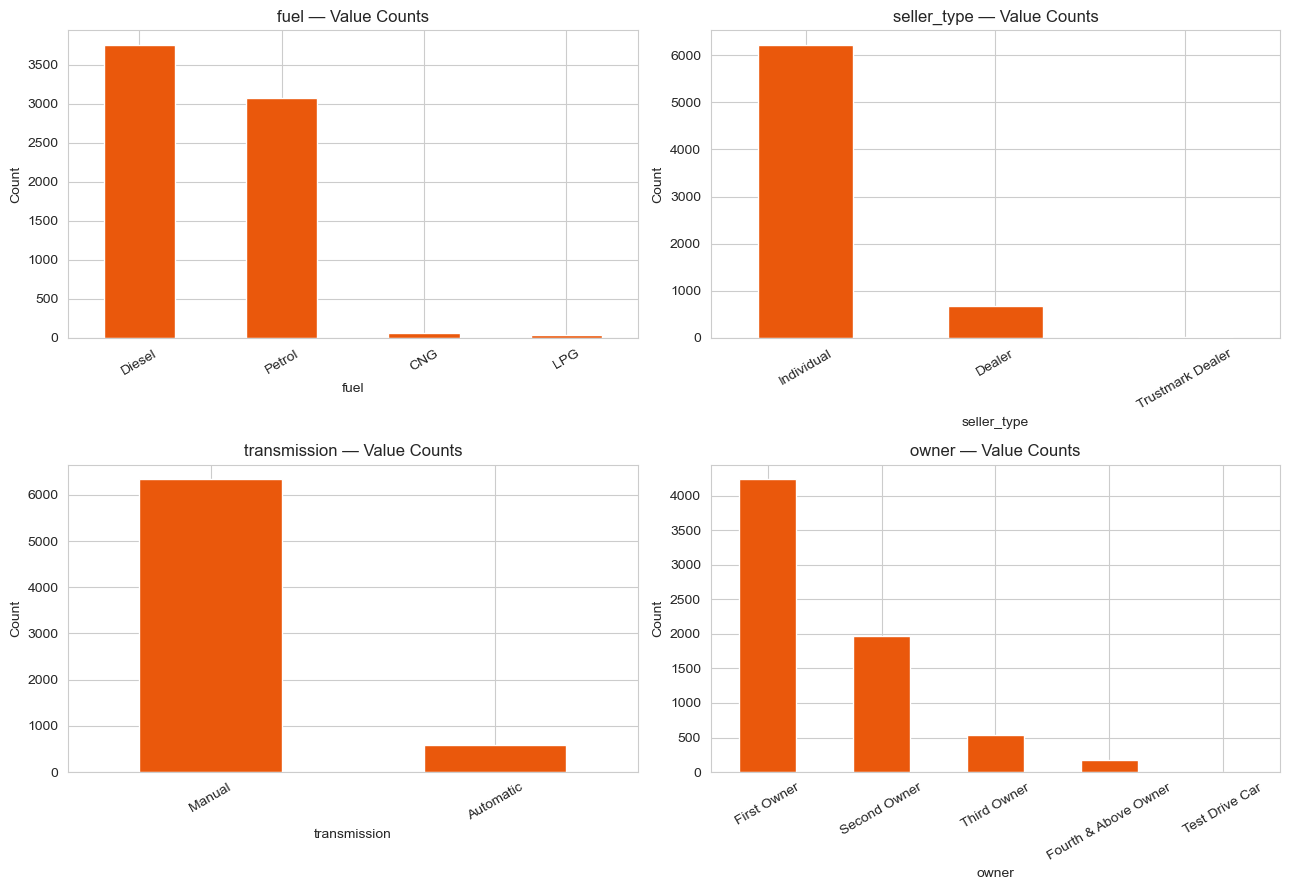

In [12]:
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, cat_cols):
    df[col].value_counts().plot(kind='bar', ax=ax, color='#ea580c')
    ax.set_title(f'{col} — Value Counts')
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'categorical_distributions.png', dpi=150)
plt.show()

## 11. Correlation Matrix

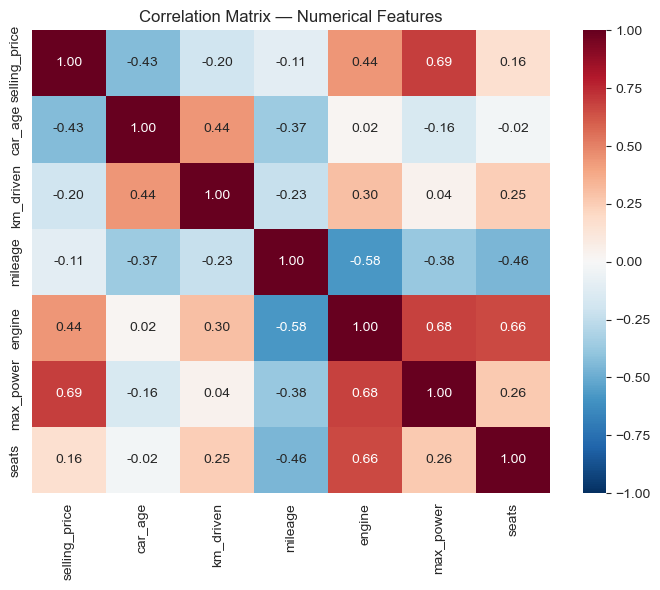

selling_price    1.000000
max_power        0.691691
engine           0.442954
seats            0.158158
mileage         -0.108361
km_driven       -0.199379
car_age         -0.433170
Name: selling_price, dtype: float64

In [13]:
numeric_for_corr = ['selling_price', 'car_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
corr = df[numeric_for_corr].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix — Numerical Features')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'correlation_matrix.png', dpi=150)
plt.show()
corr['selling_price'].sort_values(ascending=False)

## 12. Price vs Car Age

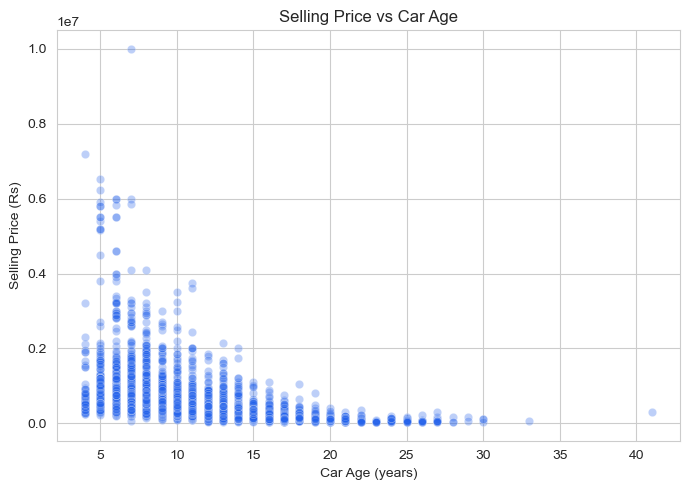

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='car_age', y='selling_price', alpha=0.3, ax=ax, color='#2563eb')
ax.set_title('Selling Price vs Car Age'); ax.set_xlabel('Car Age (years)'); ax.set_ylabel('Selling Price (Rs)')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'price_vs_age.png', dpi=150); plt.show()

## 13. Price vs Kilometers Driven

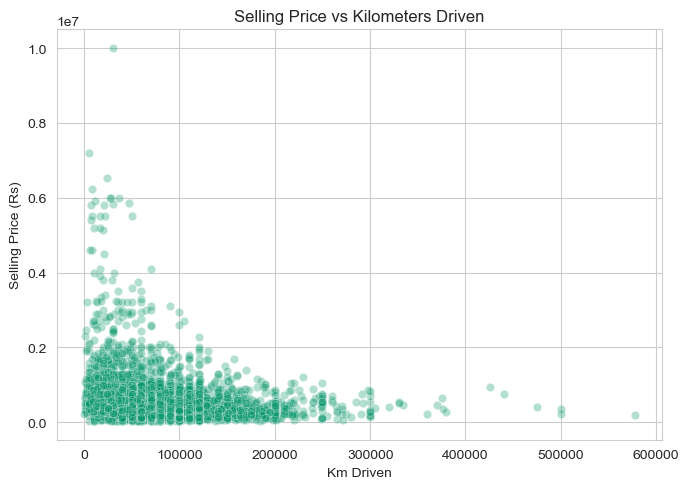

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='km_driven', y='selling_price', alpha=0.3, ax=ax, color='#059669')
ax.set_title('Selling Price vs Kilometers Driven'); ax.set_xlabel('Km Driven'); ax.set_ylabel('Selling Price (Rs)')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'price_vs_km.png', dpi=150); plt.show()

## 14. Price vs Mileage

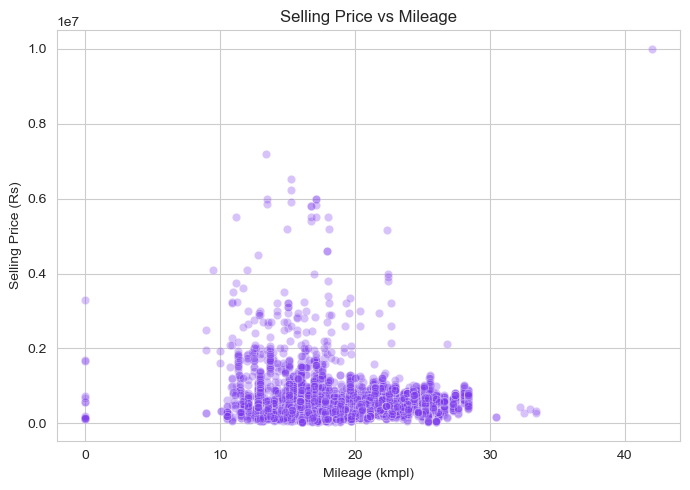

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='mileage', y='selling_price', alpha=0.3, ax=ax, color='#7c3aed')
ax.set_title('Selling Price vs Mileage'); ax.set_xlabel('Mileage (kmpl)'); ax.set_ylabel('Selling Price (Rs)')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'price_vs_mileage.png', dpi=150); plt.show()

## 15. Price vs Engine Capacity

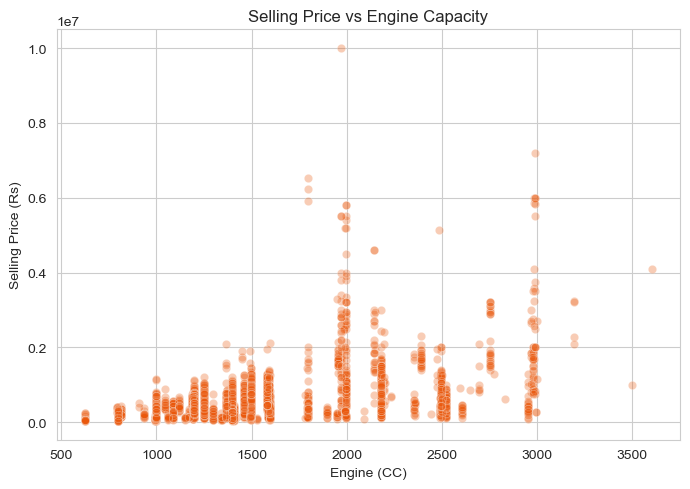

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='engine', y='selling_price', alpha=0.3, ax=ax, color='#ea580c')
ax.set_title('Selling Price vs Engine Capacity'); ax.set_xlabel('Engine (CC)'); ax.set_ylabel('Selling Price (Rs)')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'price_vs_engine.png', dpi=150); plt.show()

## 16. Price by Fuel Type

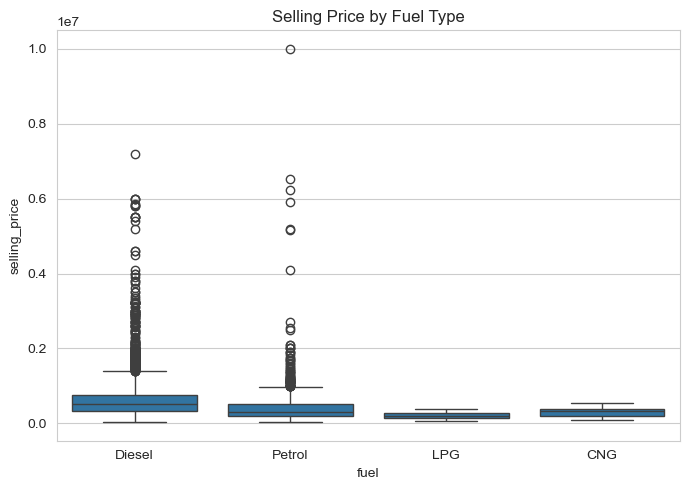

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='fuel', y='selling_price', ax=ax)
ax.set_title('Selling Price by Fuel Type')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'price_by_fuel.png', dpi=150); plt.show()

## 17. Price by Transmission

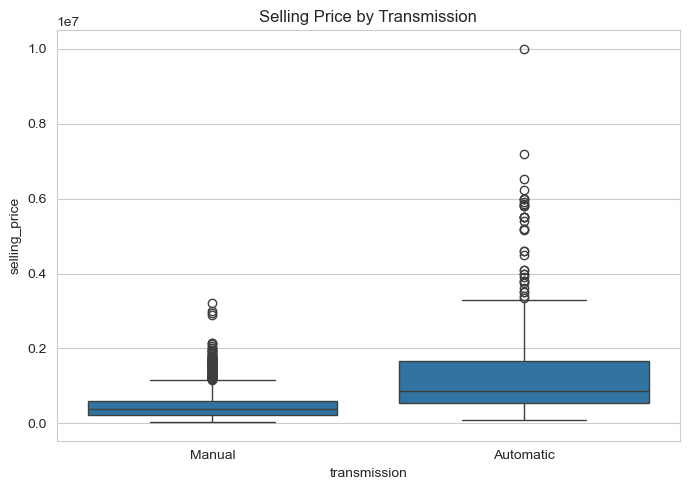

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='transmission', y='selling_price', ax=ax)
ax.set_title('Selling Price by Transmission')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'price_by_transmission.png', dpi=150); plt.show()

## 18. Price by Seller Type

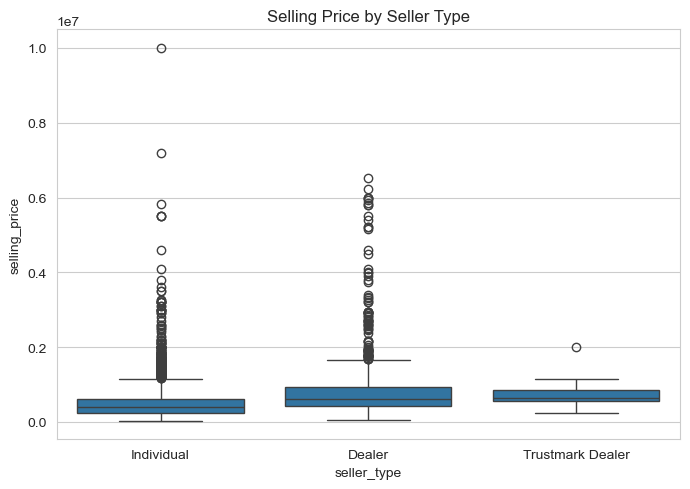

In [20]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='seller_type', y='selling_price', ax=ax)
ax.set_title('Selling Price by Seller Type')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'price_by_seller_type.png', dpi=150); plt.show()

## 19. Outlier Analysis

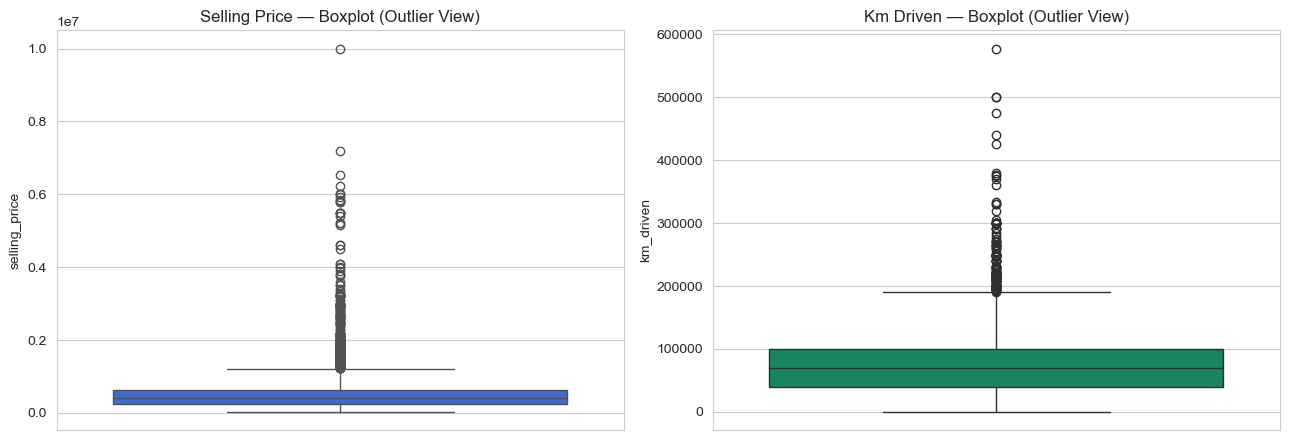

Selling price IQR outlier fence (upper): Rs 1,210,625
Rows above fence: 327 (4.7%)
These are not removed from training: they represent genuine premium-vehicle listings, not data-entry errors, so removing them would bias the model against high-value cars.


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(y=df['selling_price'], ax=axes[0], color='#2563eb')
axes[0].set_title('Selling Price — Boxplot (Outlier View)')
sns.boxplot(y=df['km_driven'], ax=axes[1], color='#059669')
axes[1].set_title('Km Driven — Boxplot (Outlier View)')
fig.tight_layout(); fig.savefig(FIGURES_DIR / 'outlier_analysis.png', dpi=150); plt.show()

q1, q3 = df['selling_price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
n_outliers = (df['selling_price'] > upper_fence).sum()
print(f'Selling price IQR outlier fence (upper): Rs {upper_fence:,.0f}')
print(f'Rows above fence: {n_outliers} ({n_outliers/len(df)*100:.1f}%)')
print('These are not removed from training: they represent genuine premium-vehicle listings, not data-entry errors, so removing them would bias the model against high-value cars.')

## Summary
- Selling price is right-skewed with a long tail of premium vehicles.
- `car_age` and `km_driven` show the expected negative correlation with price.
- `max_power` and `engine` show the strongest positive correlation with price among numeric features.
- Fuel type, transmission, and seller type all show visible price differences by category.
- A small number of high-price outliers exist but are genuine listings, not retained data errors — kept in training rather than dropped.

These findings directly motivate the feature set and preprocessing choices in `src/feature_engineering.py` and `src/preprocessing.py`.